# Insurance Cost Prediction with a Neural Network

## Project Objective
Build and train a neural network using Keras to predict medical insurance charges based on personal characteristics.

## Target Variable
- `charges`

## Problem Type
- Regression

In [3]:
import sys
print(sys.executable)

/home/userchompiraz_/projects/insurance_nn_project/.venv/bin/python


In [ ]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [ ]:
#load Dataset
df = pd.read_csv("https://raw.githubusercontent.com/TripleTen-DS/Dataset/refs/heads/main/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
# Data Exploration
df.shape
df.info()
df.isna().sum()
df.describe()
df.describe(include="object")

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


/tmp/ipykernel_9017/2746983461.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


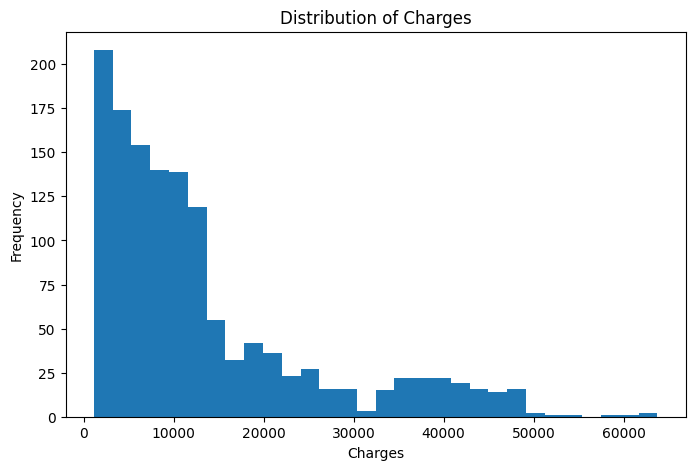

In [8]:
# plot targer distribution
plt.figure(figsize=(8,5))
plt.hist(df['charges'], bins=30)
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.title('Distribution of Charges')
plt.show()

In [9]:
# summary cell 
df["charges"].describe()

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

## Initial Observations

- This dataset includes 1,338 insurance records and 7 total columns.
- No missing values were found, so no imputation is needed at this stage.
- The categorical input features are `sex`, `smoker`, and `region`.
- The numerical input features are `age`, `bmi`, and `children`.
- The target variable is `charges`, which makes this a regression problem because the model must predict a continuous numeric value.
- The distribution of `charges` is right-skewed, meaning most beneficiaries have lower charges, while a smaller group has much higher costs.
- Since `charges` spans a wide range of values, scaling the target may improve training stability for the neural network.